# Early Warning System for Risk-Off Market Regimes

## Research Question

**Can market volatility and cross-asset indicators provide an early warning of risk-off market regimes?**

This notebook is a project-oriented version of the lecture code. It stays within the lecture syllabus:

- stationarity transformation
- train / validation / test split
- `StandardScaler` without data leakage
- MVG, SVM, Autoencoder, Isolation Forest
- threshold selection
- Precision, Recall, F1, ROC-AUC

The main change is that we build an **early-warning target**:

> Market indicators at week **t** are used to detect whether the market will be **risk-off at week t+1**.

So this is not only a contemporaneous classifier; it is an Early Warning System.


In [2]:
# ============================================================
# SETUP — LOCAL JUPYTER VERSION
# ============================================================
import sys
import subprocess
import importlib.util
from pathlib import Path
import warnings
from IPython.display import display

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "statsmodels": "statsmodels",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "torch": "torch",
}

for import_name, pip_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import multivariate_normal
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.svm import SVC
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)

print("✅ Setup complete")
print("Python:", sys.version.split()[0])
print("Working folder:", Path.cwd())


✅ Setup complete
Python: 3.11.5
Working folder: C:\Users\Omen


---
# 1. Load the Excel Dataset

The Excel file has two sheets. The first sheet contains the market data; the second sheet is metadata. We therefore load `sheet_name=0`.


In [3]:
# ============================================================
# DATA PATH — DESKTOP OR SAME FOLDER AS NOTEBOOK
# ============================================================
candidate_file_names = [
    "04 May Zenti exercises.xlsx",
    "04 May Zenti exercises(1).xlsx",
    "04 May Zenti exercises(2).xlsx",
    "04 May Zenti exercises(3).xlsx",
]

search_folders = [Path.home() / "Desktop", Path.cwd()]
file_path = None
for folder in search_folders:
    for fname in candidate_file_names:
        candidate = folder / fname
        if candidate.exists():
            file_path = candidate
            break
    if file_path is not None:
        break

if file_path is None:
    raise FileNotFoundError(
        "Excel file not found. Put '04 May Zenti exercises.xlsx' on your Desktop "
        "or in the same folder as this notebook."
    )

print(f"✅ Excel file found: {file_path}")

excel_file = pd.ExcelFile(file_path, engine="openpyxl")
print("Sheets found:", excel_file.sheet_names)

data_df = pd.read_excel(file_path, sheet_name=0, engine="openpyxl")
metadata_df = pd.read_excel(file_path, sheet_name=1, engine="openpyxl") if len(excel_file.sheet_names) > 1 else None

data_df.columns = [str(c).strip() for c in data_df.columns]

if "Date" in data_df.columns:
    date_col = "Date"
elif "Data" in data_df.columns:
    date_col = "Data"
else:
    date_col = data_df.columns[0]

if "Y" not in data_df.columns:
    raise ValueError("Column 'Y' was not found in the first sheet.")

data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True, errors="coerce")
data_df = data_df.dropna(subset=[date_col]).set_index(date_col).sort_index()
data_df = data_df.apply(pd.to_numeric, errors="coerce").dropna()

Y_current = data_df["Y"].astype(int)
X_df = data_df.drop(columns=["Y"])

print(f"Data shape: {X_df.shape[0]} weekly observations × {X_df.shape[1]} indicators")
print(f"Period: {X_df.index.min().date()} → {X_df.index.max().date()}")
print(f"Current risk-off prevalence: {Y_current.mean()*100:.1f}%")
display(X_df.head())


✅ Excel file found: C:\Users\Omen\Desktop\04 May Zenti exercises.xlsx
Sheets found: ['Markets', 'Metadata']
Data shape: 1111 weekly observations × 42 indicators
Period: 2000-01-11 → 2021-04-20
Current risk-off prevalence: 21.3%


,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXIN,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,217.34,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,227.08,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,233.00,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,237.48,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,258.02,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40


---
# 2. Cross-Asset Indicator Groups

The research question mentions **market volatility** and **cross-asset indicators**. We group the existing dataset variables into volatility, equity, bonds, rates/yields, FX, commodities/gold and macro surprise.


In [4]:
# ============================================================
# CROSS-ASSET GROUPS
# ============================================================
feature_groups = {
    "Volatility": ["VIX"],
    "Equity": ["MXUS", "MXEU", "MXJP", "MXCN", "MXIN", "MXBR", "MXRU"],
    "Bond indices": ["EMUSTRUU", "LF94TRUU", "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU"],
    "Rates/Yields": ["EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
                     "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
                     "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"],
    "FX": ["DXY", "GBP", "JPY"],
    "Commodities/Gold": ["XAUBGNL", "BDIY", "CRY", "Cl1"],
    "Macro": ["ECSURPUS"],
}

feature_groups = {g: [c for c in cols if c in X_df.columns] for g, cols in feature_groups.items()}
feature_groups = {g: cols for g, cols in feature_groups.items() if len(cols) > 0}

group_summary = pd.DataFrame({
    "Group": list(feature_groups.keys()),
    "N indicators": [len(v) for v in feature_groups.values()],
    "Indicators": [", ".join(v) for v in feature_groups.values()]
})
display(group_summary)


,Group,N indicators,Indicators
0,Volatility,1,VIX
1,Equity,7,"MXUS, MXEU, MXJP, MXCN, MXIN, MXBR, MXRU"
2,Bond indices,8,"EMUSTRUU, LF94TRUU, LF98TRUU, LG30TRUU, LMBITR..."
3,Rates/Yields,18,"EONIA, GTDEM10Y, GTDEM2Y, GTDEM30Y, GTGBP20Y, ..."
4,FX,3,"DXY, GBP, JPY"
5,Commodities/Gold,4,"XAUBGNL, BDIY, CRY, Cl1"
6,Macro,1,ECSURPUS


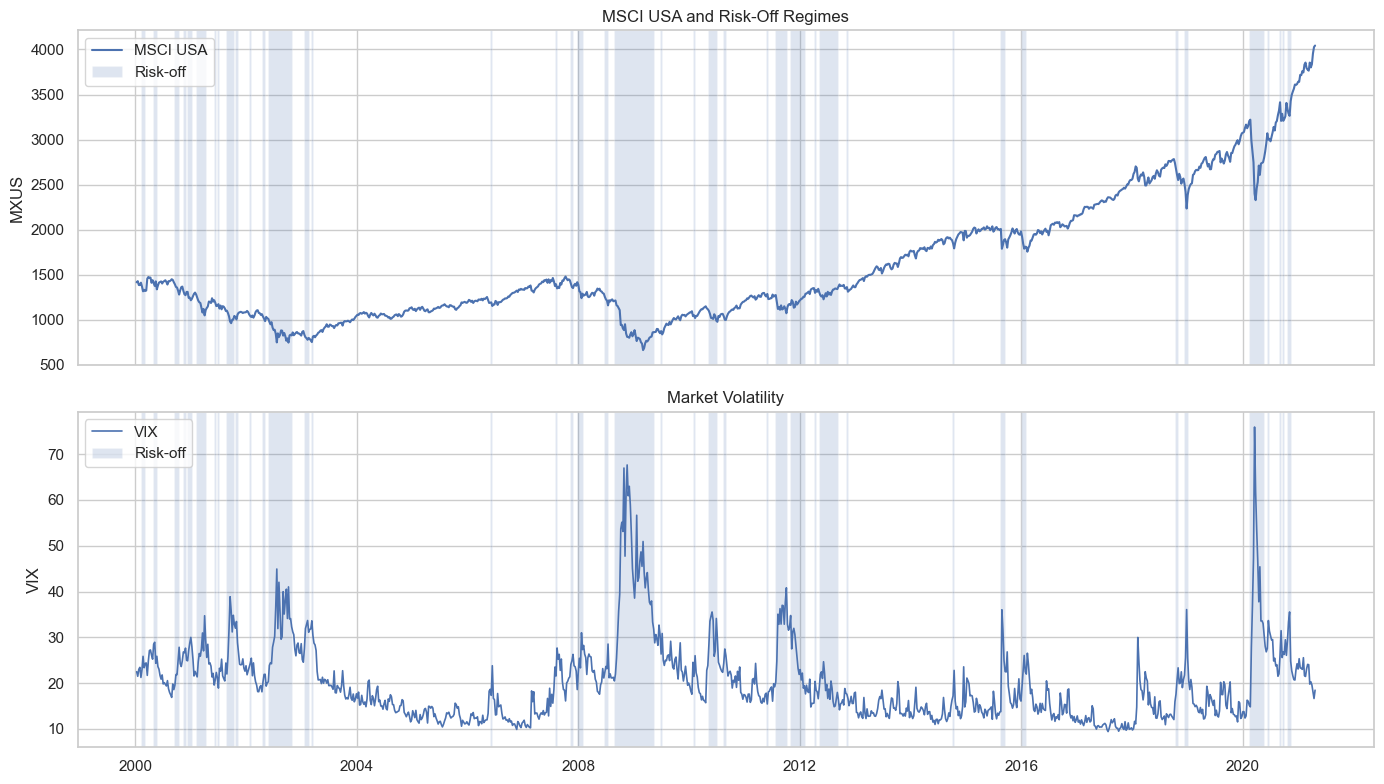

In [5]:
# Visual motivation: equity index, volatility and risk-off windows
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

if "MXUS" in X_df.columns:
    axes[0].plot(X_df.index, X_df["MXUS"], linewidth=1.5, label="MSCI USA")
    axes[0].set_ylabel("MXUS")
    axes[0].set_title("MSCI USA and Risk-Off Regimes")

if "VIX" in X_df.columns:
    axes[1].plot(X_df.index, X_df["VIX"], linewidth=1.2, label="VIX")
    axes[1].set_ylabel("VIX")
    axes[1].set_title("Market Volatility")

in_riskoff, start_date, first_label = False, None, True
for date, label in Y_current.items():
    if label == 1 and not in_riskoff:
        start_date, in_riskoff = date, True
    elif label == 0 and in_riskoff:
        for ax in axes:
            ax.axvspan(start_date, date, alpha=0.18, label="Risk-off" if first_label else None)
        first_label = False
        in_riskoff = False
if in_riskoff:
    for ax in axes:
        ax.axvspan(start_date, Y_current.index[-1], alpha=0.18)

for ax in axes:
    ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


---
# 3. Stationarity and Early-Warning Target

Lecture logic: raw prices are not stationary, so we transform them.

| Variable type | Transformation |
|---|---|
| Indices / FX / commodities / VIX / bond indices | Log-returns |
| Rates and yields | First differences |
| Economic surprise index | Kept as level |

Then we create the early-warning label:

\[
X_t \rightarrow Y_{t+1}
\]

So the model uses this week's indicators to detect next week's risk-off regime.


In [6]:
# ============================================================
# STATIONARITY TRANSFORMATION
# ============================================================
log_return_features = [col for col in X_df.columns if col in [
    "XAUBGNL", "BDIY", "CRY", "Cl1", "DXY", "EMUSTRUU", "GBP", "JPY", "LF94TRUU",
    "LF98TRUU", "LG30TRUU", "LMBITR", "LP01TREU", "LUACTRUU", "LUMSTRUU",
    "MXBR", "MXCN", "MXEU", "MXIN", "MXJP", "MXRU", "MXUS", "VIX"
]]

rate_diff_features = [col for col in X_df.columns if col in [
    "EONIA", "GTDEM10Y", "GTDEM2Y", "GTDEM30Y", "GTGBP20Y", "GTGBP2Y", "GTGBP30Y",
    "GTITL10YR", "GTITL2YR", "GTITL30YR", "GTJPY10YR", "GTJPY2YR", "GTJPY30YR",
    "US0001M", "USGG3M", "USGG2YR", "GT10", "USGG30YR"
]]

stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in log_return_features:
    if (X_df[col] <= 0).any():
        stationary_df[col] = np.diff(X_df[col].values)
    else:
        stationary_df[col] = np.diff(np.log(X_df[col].values))

for col in rate_diff_features:
    stationary_df[col] = np.diff(X_df[col].values)

if "ECSURPUS" in X_df.columns:
    stationary_df["ECSURPUS"] = X_df["ECSURPUS"].values[1:]

stationary_df = stationary_df.replace([np.inf, -np.inf], np.nan).dropna()

# Current label aligned with transformed features
Y_current_aligned = Y_current.loc[stationary_df.index].astype(int)

# Early-warning label: next week's risk-off state
Y_next_week = Y_current.shift(-1).loc[stationary_df.index]

# Last observation has no next-week label, so remove it.
valid_idx = Y_next_week.dropna().index
stationary_df = stationary_df.loc[valid_idx]
Y_current_aligned = Y_current_aligned.loc[valid_idx].astype(int)
Y_early = Y_next_week.loc[valid_idx].astype(int)

features = stationary_df.columns.tolist()

print(f"Stationary matrix: {stationary_df.shape[0]} weeks × {stationary_df.shape[1]} indicators")
print(f"Current Y=1 prevalence: {Y_current_aligned.mean()*100:.1f}%")
print(f"Next-week Y=1 prevalence: {Y_early.mean()*100:.1f}%")
display(stationary_df.head())


Stationary matrix: 1109 weeks × 42 indicators
Current Y=1 prevalence: 21.4%
Next-week Y=1 prevalence: 21.4%


,BDIY,CRY,Cl1,DXY,EMUSTRUU,GBP,JPY,LF94TRUU,LF98TRUU,LG30TRUU,...,GTITL2YR,GTITL30YR,GTJPY10YR,GTJPY2YR,GTJPY30YR,US0001M,USGG2YR,USGG30YR,USGG3M,ECSURPUS
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-18,0.012173,0.048106,0.112899,0.012845,0.003682,-0.004689,-0.003691,0.00000,-0.000660,0.000805,...,0.040,0.138,0.056,0.003,-0.004,0.02125,0.037,0.076,-0.048,0.043
2000-01-25,-0.026687,0.013424,-0.019955,0.005385,0.004366,0.006874,0.005390,0.00000,0.001867,0.002874,...,-0.024,-0.178,-0.140,-0.056,-0.159,0.01625,-0.033,-0.113,0.184,0.135
2000-02-01,-0.042560,-0.002335,-0.002124,0.024214,-0.001929,-0.023926,0.016925,-0.01165,0.001243,-0.000603,...,0.029,-0.093,0.145,0.071,0.071,0.06625,0.142,-0.211,0.146,0.191
2000-02-08,-0.026277,-0.008547,-0.007112,-0.006694,0.024993,0.000124,0.013355,0.00000,0.001588,0.011307,...,0.098,-0.070,0.149,-0.005,0.151,0.00625,0.104,-0.192,-0.031,0.312
2000-02-15,0.086946,0.024777,0.070277,0.004500,0.009644,-0.008855,-0.005229,0.00000,-0.000146,0.003551,...,0.013,0.053,-0.118,-0.026,-0.172,-0.01125,-0.050,0.015,0.063,0.391


In [7]:
# ADF stationarity check on selected variables
# H0: non-stationary. p < 0.05 suggests stationarity.
def adf_check(series, name):
    series = pd.Series(series).dropna()
    stat, pval = adfuller(series, autolag="AIC")[:2]
    status = "Stationary" if pval < 0.05 else "Non-stationary"
    print(f"{name:12s} | p-value={pval:.4f} → {status}")

selected = [c for c in ["MXUS", "MXEU", "VIX", "GT10", "GTITL10YR"] if c in X_df.columns]

print("Original levels:")
for col in selected:
    adf_check(X_df[col], col)

print("\nAfter transformation:")
for col in selected:
    if col in stationary_df.columns:
        adf_check(stationary_df[col], col)


Original levels:
MXUS         | p-value=1.0000 → Non-stationary
MXEU         | p-value=0.3900 → Non-stationary
VIX          | p-value=0.0016 → Stationary
GT10         | p-value=0.1684 → Non-stationary
GTITL10YR    | p-value=0.7544 → Non-stationary

After transformation:
MXUS         | p-value=0.0000 → Stationary
MXEU         | p-value=0.0000 → Stationary
VIX          | p-value=0.0000 → Stationary
GT10         | p-value=0.0000 → Stationary
GTITL10YR    | p-value=0.0000 → Stationary


---
# 4. Does Cross-Asset Signal Intensity Increase Before Risk-Off?

This simple diagnostic directly addresses the research question. For each group, we compare the average absolute movement before normal weeks versus before next-week risk-off weeks.


,Group,Mean before normal,Mean before next-week risk-off,Risk-off / normal ratio,N indicators
2,Bond indices,0.0050,0.0088,1.7663,8
1,Equity,0.0234,0.0373,1.5984,7
3,Rates/Yields,0.0600,0.0874,1.4583,18
5,Commodities/Gold,0.0324,0.0419,1.2930,4
0,Volatility,0.0884,0.1133,1.2812,1
4,FX,0.0089,0.0113,1.2762,3
6,Macro,0.2679,0.3222,1.2027,1


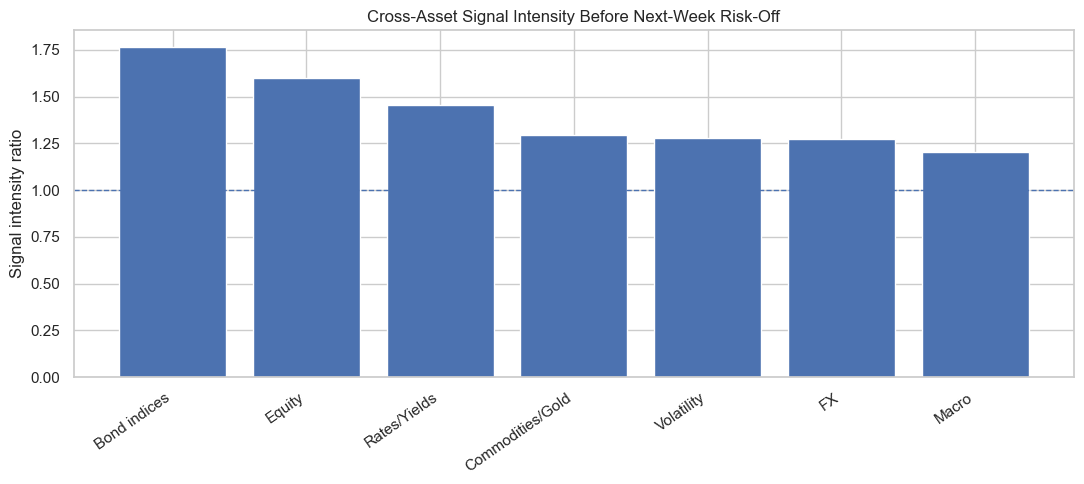

In [8]:
# ============================================================
# CROSS-ASSET SIGNAL INTENSITY
# ============================================================
group_rows = []
for group, cols in feature_groups.items():
    cols = [c for c in cols if c in stationary_df.columns]
    if len(cols) == 0:
        continue
    group_signal = stationary_df[cols].abs().mean(axis=1)
    normal_mean = group_signal[Y_early == 0].mean()
    warning_mean = group_signal[Y_early == 1].mean()
    ratio = warning_mean / normal_mean if normal_mean != 0 else np.nan
    group_rows.append({
        "Group": group,
        "Mean before normal": normal_mean,
        "Mean before next-week risk-off": warning_mean,
        "Risk-off / normal ratio": ratio,
        "N indicators": len(cols),
    })

group_signal_df = pd.DataFrame(group_rows).sort_values("Risk-off / normal ratio", ascending=False)
display(group_signal_df.round(4))

plt.figure(figsize=(11, 5))
plt.bar(group_signal_df["Group"], group_signal_df["Risk-off / normal ratio"])
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("Signal intensity ratio")
plt.title("Cross-Asset Signal Intensity Before Next-Week Risk-Off")
plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()


---
# 5. Chronological Split and Scaling

For an EWS, we should avoid random shuffling because that may allow future information to influence the past. We use a chronological split:

- 60% train
- 20% validation
- 20% test

The scaler is fitted only on training data.


In [9]:
# ============================================================
# CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================
X_all = stationary_df.values
Y_all = Y_early.values
Date_all = stationary_df.index

n = len(stationary_df)
train_end = int(0.60 * n)
cv_end = int(0.80 * n)

X_train_raw, y_train = X_all[:train_end], Y_all[:train_end]
X_cv_raw, y_cv = X_all[train_end:cv_end], Y_all[train_end:cv_end]
X_test_raw, y_test = X_all[cv_end:], Y_all[cv_end:]

dates_train = Date_all[:train_end]
dates_cv = Date_all[train_end:cv_end]
dates_test = Date_all[cv_end:]

# Unsupervised models learn normal behavior from normal training weeks only.
X_train_normal_raw = X_train_raw[y_train == 0]

# Fit scaler on training period only. Here we fit on normal training data because normality is the reference distribution.
scaler = StandardScaler()
X_train_normal_sc = scaler.fit_transform(X_train_normal_raw)
X_train_sc = scaler.transform(X_train_raw)
X_cv_sc = scaler.transform(X_cv_raw)
X_test_sc = scaler.transform(X_test_raw)

split_table = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Start": [dates_train.min().date(), dates_cv.min().date(), dates_test.min().date()],
    "End": [dates_train.max().date(), dates_cv.max().date(), dates_test.max().date()],
    "Observations": [len(y_train), len(y_cv), len(y_test)],
    "Next-week risk-off prevalence": [y_train.mean(), y_cv.mean(), y_test.mean()],
})
display(split_table)

print(f"Normal training observations for MVG/AE/IF: {len(X_train_normal_sc)}")


,Set,Start,End,Observations,Next-week risk-off prevalence
0,Train,2000-01-18,2012-10-09,665,0.291729
1,Validation,2012-10-16,2017-01-10,222,0.063063
2,Test,2017-01-17,2021-04-13,222,0.130631


Normal training observations for MVG/AE/IF: 471


In [10]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================
def tune_threshold_max_f1(scores, y_true):
    """Choose threshold on validation set to maximize F1. Higher score = higher risk."""
    scores = np.asarray(scores)
    y_true = np.asarray(y_true).astype(int)
    thresholds = np.unique(np.quantile(scores, np.linspace(0.01, 0.99, 300)))
    best = {"threshold": thresholds[0], "f1": -1, "precision": 0, "recall": 0}
    for thr in thresholds:
        pred = (scores >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {
                "threshold": thr,
                "f1": f1,
                "precision": precision_score(y_true, pred, zero_division=0),
                "recall": recall_score(y_true, pred, zero_division=0),
            }
    return best


def evaluate_model(name, y_true, y_pred, scores):
    return {
        "Model": name,
        "ROC-AUC": roc_auc_score(y_true, scores),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


def plot_confusion_and_roc(name, y_true, y_pred, scores):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=["Normal next week", "Risk-off next week"],
        cmap="Blues", ax=axes[0]
    )
    axes[0].set_title(f"Confusion Matrix — {name}")
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)
    axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC={auc_value:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate / Recall")
    axes[1].set_title(f"ROC Curve — {name}")
    axes[1].legend()
    plt.tight_layout(); plt.show()


---
# 6. Model 1 — Multivariate Gaussian Baseline

MVG learns the distribution of normal market behavior. A very low probability under that normal distribution becomes an anomaly / risk score.


MVG validation threshold: {'threshold': np.float64(-2.60974069044733e-13), 'f1': 0.1339712918660287, 'precision': 0.07179487179487179, 'recall': 1.0}

=== MVG — Test Set ===
                    precision    recall  f1-score   support

  Normal next week       0.94      0.25      0.39       193
Risk-off next week       0.15      0.90      0.26        29

          accuracy                           0.33       222
         macro avg       0.55      0.57      0.33       222
      weighted avg       0.84      0.33      0.38       222



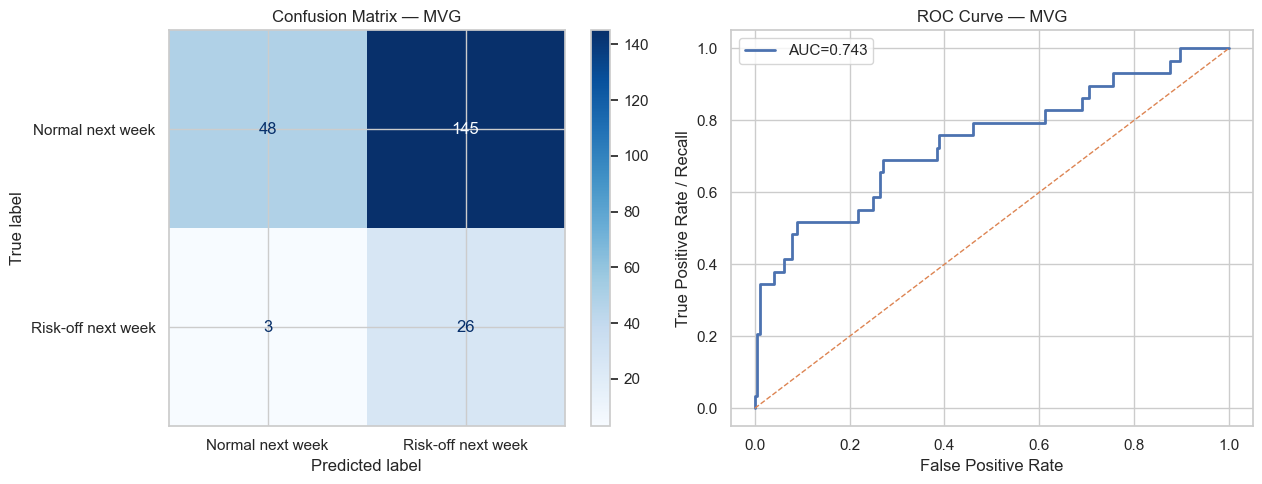

In [11]:
# ============================================================
# MVG BASELINE
# ============================================================
mu_mvg = X_train_normal_sc.mean(axis=0)
sigma_mvg = np.cov(X_train_normal_sc, rowvar=False)
sigma_mvg_reg = sigma_mvg + np.eye(sigma_mvg.shape[0]) * 1e-6

def mvg_pdf(X, mu, sigma):
    rv = multivariate_normal(mean=mu, cov=sigma, allow_singular=True)
    return rv.pdf(X)

# Higher score = more risky
mvg_score_cv = -mvg_pdf(X_cv_sc, mu_mvg, sigma_mvg_reg)
mvg_score_test = -mvg_pdf(X_test_sc, mu_mvg, sigma_mvg_reg)

mvg_thr = tune_threshold_max_f1(mvg_score_cv, y_cv)
y_pred_mvg = (mvg_score_test >= mvg_thr["threshold"]).astype(int)

print("MVG validation threshold:", mvg_thr)
print("\n=== MVG — Test Set ===")
print(classification_report(y_test, y_pred_mvg, target_names=["Normal next week", "Risk-off next week"]))
plot_confusion_and_roc("MVG", y_test, y_pred_mvg, mvg_score_test)


---
# 7. Model 2 — Support Vector Machine

SVM is the supervised lecture model. We use class balancing because risk-off observations are less frequent.


SVM validation threshold: {'threshold': np.float64(0.2466088698853076), 'f1': 0.23214285714285715, 'precision': 0.1326530612244898, 'recall': 0.9285714285714286}

=== SVM — Test Set ===
                    precision    recall  f1-score   support

  Normal next week       0.91      0.67      0.77       193
Risk-off next week       0.21      0.59      0.31        29

          accuracy                           0.66       222
         macro avg       0.56      0.63      0.54       222
      weighted avg       0.82      0.66      0.71       222



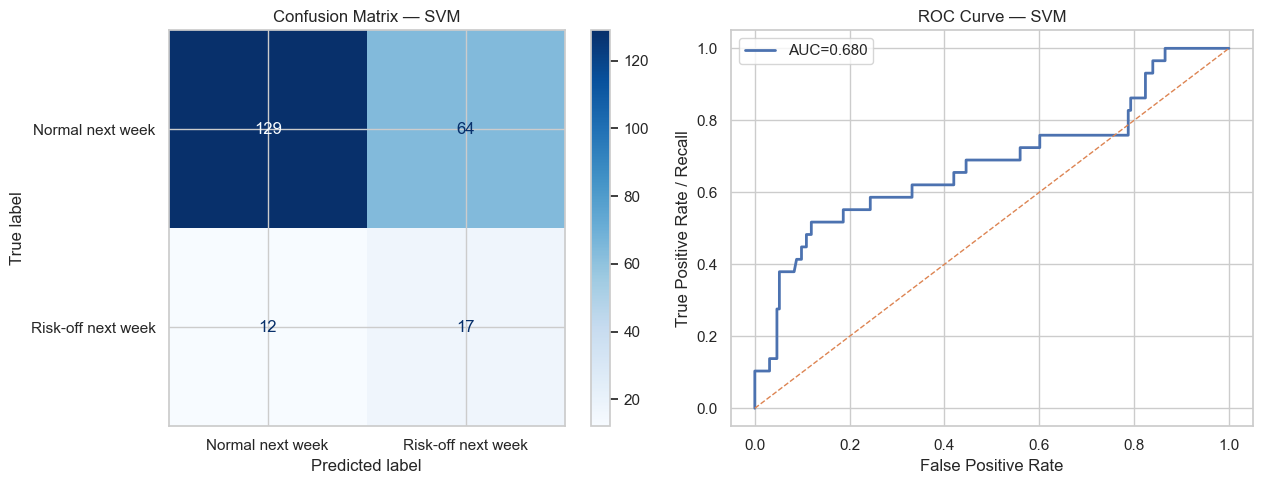

In [12]:
# ============================================================
# SVM
# ============================================================
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=SEED,
)
svm.fit(X_train_sc, y_train)

svm_score_cv = svm.predict_proba(X_cv_sc)[:, 1]
svm_score_test = svm.predict_proba(X_test_sc)[:, 1]

svm_thr = tune_threshold_max_f1(svm_score_cv, y_cv)
y_pred_svm = (svm_score_test >= svm_thr["threshold"]).astype(int)

print("SVM validation threshold:", svm_thr)
print("\n=== SVM — Test Set ===")
print(classification_report(y_test, y_pred_svm, target_names=["Normal next week", "Risk-off next week"]))
plot_confusion_and_roc("SVM", y_test, y_pred_svm, svm_score_test)


---
# 8. Model 3 — Autoencoder

The Autoencoder learns to reconstruct normal market observations. A high reconstruction error means the observation is unusual.


Device: cpu


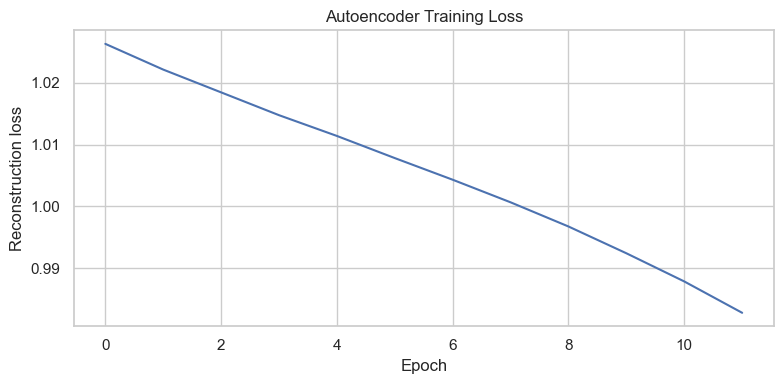

Final AE training loss: 0.982805


In [13]:
# ============================================================
# AUTOENCODER
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
# Limit CPU threads so this runs smoothly on normal laptops.
torch.set_num_threads(1)
print("Device:", DEVICE)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, layer1=24, bottleneck=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, layer1), nn.ReLU(),
            nn.Linear(layer1, bottleneck), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, layer1), nn.ReLU(),
            nn.Linear(layer1, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model_ae = Autoencoder(input_dim=X_train_normal_sc.shape[1]).to(DEVICE)
X_tr_tensor = torch.tensor(X_train_normal_sc, dtype=torch.float32).to(DEVICE)
loader = DataLoader(TensorDataset(X_tr_tensor, X_tr_tensor), batch_size=256, shuffle=True)

optimizer = optim.Adam(model_ae.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

train_losses = []
NUM_EPOCHS = 12
for epoch in range(NUM_EPOCHS):
    model_ae.train()
    total = 0.0
    for xb, _ in loader:
        optimizer.zero_grad()
        loss = criterion(model_ae(xb), xb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    epoch_loss = total / len(X_tr_tensor)
    train_losses.append(epoch_loss)

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("Autoencoder Training Loss")
plt.tight_layout(); plt.show()

print(f"Final AE training loss: {train_losses[-1]:.6f}")


Autoencoder validation threshold: {'threshold': np.float64(1.8329561137116468), 'f1': 0.14285714285714285, 'precision': 0.14285714285714285, 'recall': 0.14285714285714285}

=== Autoencoder — Test Set ===
                    precision    recall  f1-score   support

  Normal next week       0.91      0.96      0.94       193
Risk-off next week       0.61      0.38      0.47        29

          accuracy                           0.89       222
         macro avg       0.76      0.67      0.70       222
      weighted avg       0.87      0.89      0.88       222



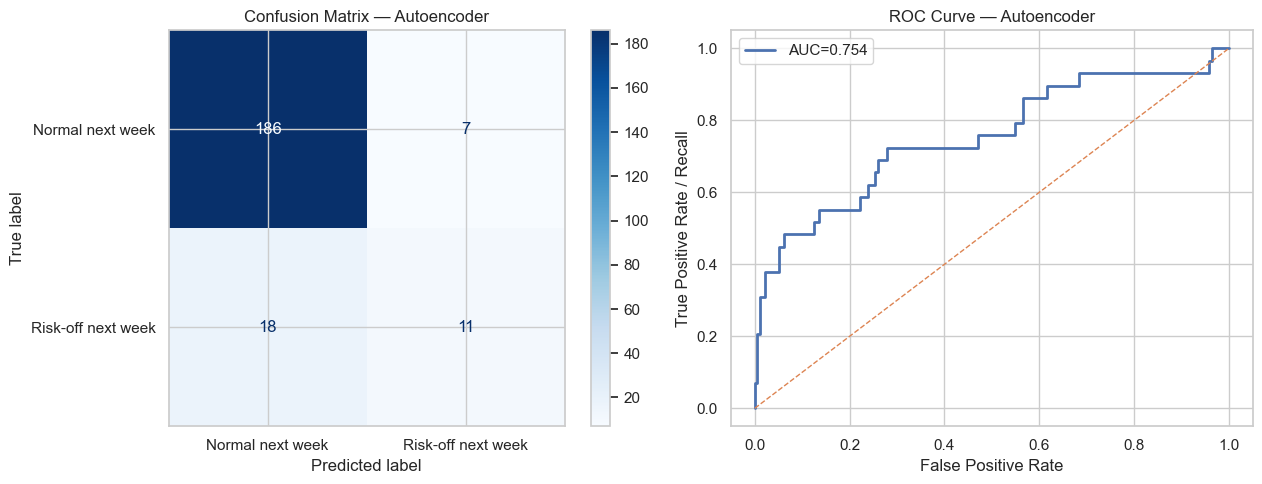

In [14]:
def reconstruction_error(model, X_np):
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
        recon = model(xt)
        return ((recon - xt) ** 2).mean(dim=1).cpu().numpy()

ae_score_cv = reconstruction_error(model_ae, X_cv_sc)
ae_score_test = reconstruction_error(model_ae, X_test_sc)

ae_thr = tune_threshold_max_f1(ae_score_cv, y_cv)
y_pred_ae = (ae_score_test >= ae_thr["threshold"]).astype(int)

print("Autoencoder validation threshold:", ae_thr)
print("\n=== Autoencoder — Test Set ===")
print(classification_report(y_test, y_pred_ae, target_names=["Normal next week", "Risk-off next week"]))
plot_confusion_and_roc("Autoencoder", y_test, y_pred_ae, ae_score_test)


---
# 9. Model 4 — Isolation Forest

Isolation Forest isolates unusual observations using random trees. Higher anomaly score means higher risk.


Isolation Forest validation threshold: {'threshold': np.float64(0.47853164980963625), 'f1': 0.15384615384615385, 'precision': 0.16666666666666666, 'recall': 0.14285714285714285}

=== Isolation Forest — Test Set ===
                    precision    recall  f1-score   support

  Normal next week       0.90      0.98      0.94       193
Risk-off next week       0.67      0.28      0.39        29

          accuracy                           0.89       222
         macro avg       0.78      0.63      0.66       222
      weighted avg       0.87      0.89      0.87       222



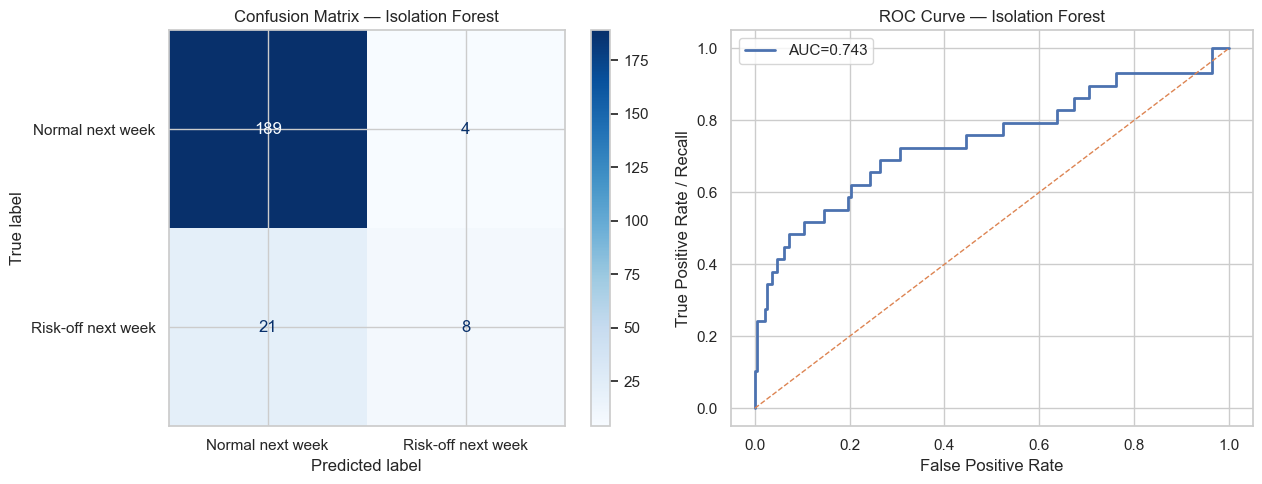

In [15]:
# ============================================================
# ISOLATION FOREST
# ============================================================
iso = IsolationForest(
    n_estimators=300,
    contamination="auto",
    max_samples="auto",
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(X_train_normal_sc)

if_score_cv = -iso.score_samples(X_cv_sc)
if_score_test = -iso.score_samples(X_test_sc)

if_thr = tune_threshold_max_f1(if_score_cv, y_cv)
y_pred_if = (if_score_test >= if_thr["threshold"]).astype(int)

print("Isolation Forest validation threshold:", if_thr)
print("\n=== Isolation Forest — Test Set ===")
print(classification_report(y_test, y_pred_if, target_names=["Normal next week", "Risk-off next week"]))
plot_confusion_and_roc("Isolation Forest", y_test, y_pred_if, if_score_test)


---
# 10. Final Comparison and Answer

The final table answers the research question. A model provides useful early warning if it achieves meaningful Recall, F1 and AUC on the chronological test set.


In [16]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================
results = [
    evaluate_model("MVG", y_test, y_pred_mvg, mvg_score_test),
    evaluate_model("SVM", y_test, y_pred_svm, svm_score_test),
    evaluate_model("Autoencoder", y_test, y_pred_ae, ae_score_test),
    evaluate_model("Isolation Forest", y_test, y_pred_if, if_score_test),
]

results_df = pd.DataFrame(results).set_index("Model")
results_sorted = results_df.sort_values("F1", ascending=False)
display(results_sorted.round(3))

best_model_name = results_sorted.index[0]
print(f"Best model by F1: {best_model_name}")


,ROC-AUC,Precision,Recall,F1
Model,,,,
Autoencoder,0.754,0.611,0.379,0.468
Isolation Forest,0.743,0.667,0.276,0.390
SVM,0.680,0.210,0.586,0.309
MVG,0.743,0.152,0.897,0.260


Best model by F1: Autoencoder


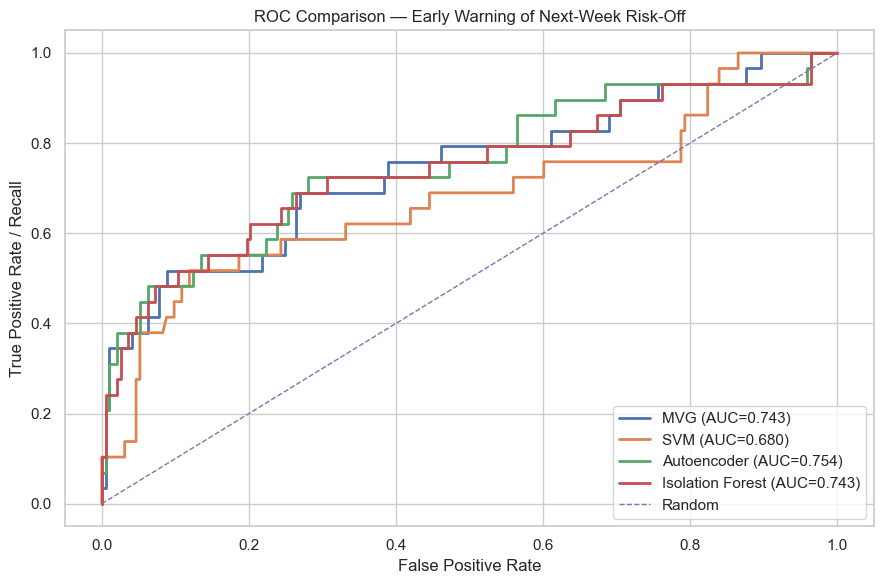

In [17]:
# ROC comparison
roc_items = [
    ("MVG", mvg_score_test),
    ("SVM", svm_score_test),
    ("Autoencoder", ae_score_test),
    ("Isolation Forest", if_score_test),
]

plt.figure(figsize=(9, 6))
for name, scores in roc_items:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Comparison — Early Warning of Next-Week Risk-Off")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()


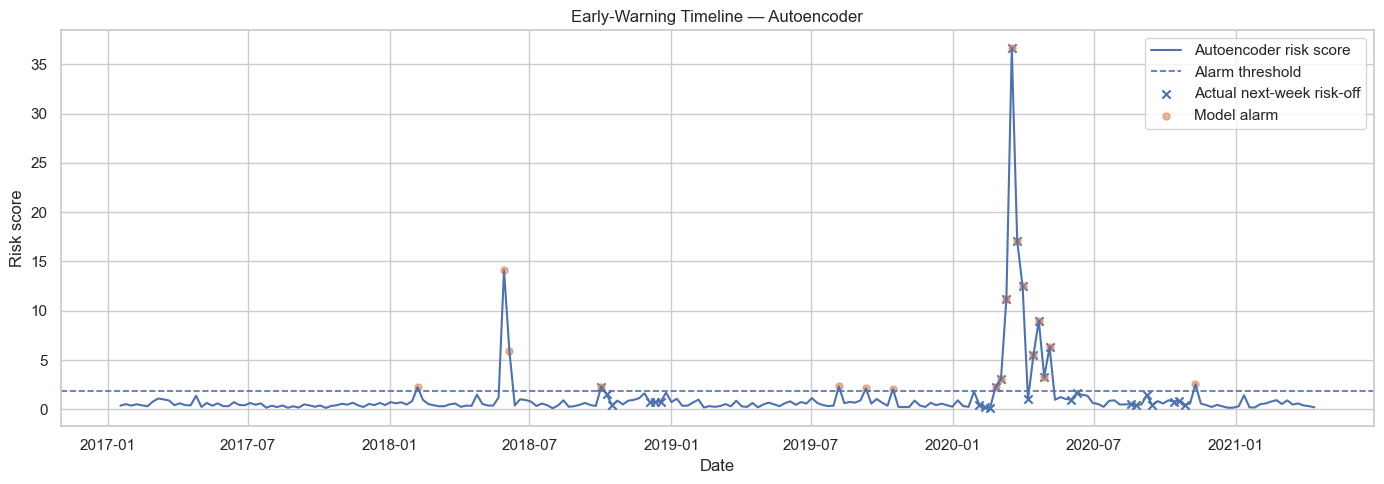

In [18]:
# Early-warning timeline for the best model
score_map = {
    "MVG": (mvg_score_test, mvg_thr["threshold"], y_pred_mvg),
    "SVM": (svm_score_test, svm_thr["threshold"], y_pred_svm),
    "Autoencoder": (ae_score_test, ae_thr["threshold"], y_pred_ae),
    "Isolation Forest": (if_score_test, if_thr["threshold"], y_pred_if),
}

best_scores, best_threshold, best_pred = score_map[best_model_name]

timeline_df = pd.DataFrame({
    "Risk score": best_scores,
    "Alarm": best_pred,
    "Actual next-week risk-off": y_test,
}, index=dates_test)

plt.figure(figsize=(14, 5))
plt.plot(timeline_df.index, timeline_df["Risk score"], linewidth=1.5, label=f"{best_model_name} risk score")
plt.axhline(best_threshold, linestyle="--", linewidth=1.2, label="Alarm threshold")

risk_idx = timeline_df.index[timeline_df["Actual next-week risk-off"] == 1]
plt.scatter(risk_idx, timeline_df.loc[risk_idx, "Risk score"], s=35, marker="x", label="Actual next-week risk-off")

alarm_idx = timeline_df.index[timeline_df["Alarm"] == 1]
plt.scatter(alarm_idx, timeline_df.loc[alarm_idx, "Risk score"], s=25, marker="o", alpha=0.6, label="Model alarm")

plt.title(f"Early-Warning Timeline — {best_model_name}")
plt.ylabel("Risk score")
plt.xlabel("Date")
plt.legend()
plt.tight_layout(); plt.show()


## Final Interpretation Template

Use the final table and timeline to complete this sentence in the slides:

> The results suggest that market volatility and cross-asset indicators **[do / do not]** provide an early warning of risk-off regimes. The strongest model is **[best model]**, because it achieves the best balance between Precision and Recall, measured by F1. In a risk-management use case, Recall is especially important because missing a crisis is more costly than producing some false alarms.


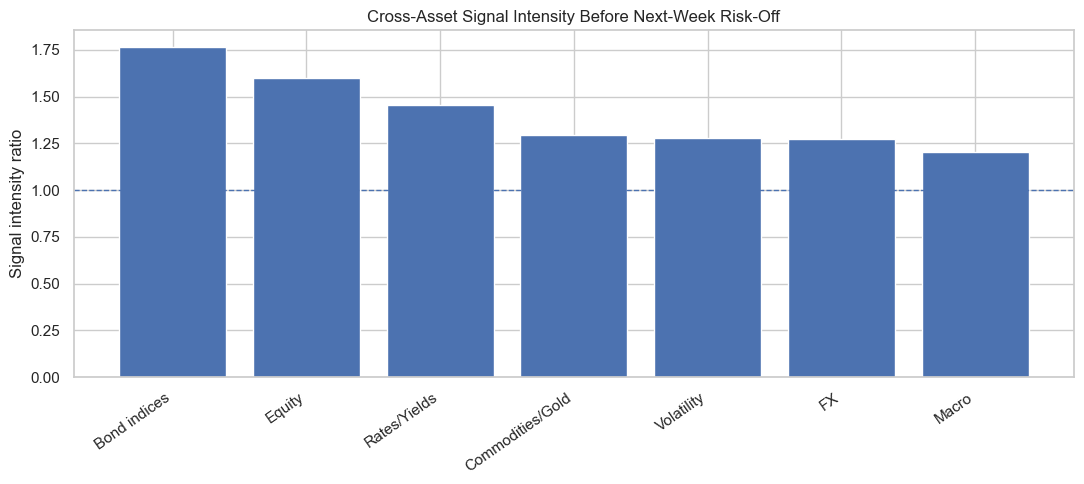

Kaydedildi:
C:\Users\Omen\Desktop\cross_asset_signal_intensity.xlsx
C:\Users\Omen\Desktop\cross_asset_signal_intensity.csv
C:\Users\Omen\Desktop\cross_asset_signal_intensity.png


In [19]:
# ============================================================
# KAYIT YOLU
# ============================================================
save_path = r"C:\Users\Omen\Desktop"

# ============================================================
# TABLOYU KAYDET
# ============================================================
group_signal_df.round(4).to_excel(
    rf"{save_path}\cross_asset_signal_intensity.xlsx",
    index=False
)

group_signal_df.round(4).to_csv(
    rf"{save_path}\cross_asset_signal_intensity.csv",
    index=False
)

# ============================================================
# GRAFİĞİ KAYDET
# ============================================================
plt.figure(figsize=(11,5))
plt.bar(
    group_signal_df["Group"],
    group_signal_df["Risk-off / normal ratio"]
)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.ylabel("Signal intensity ratio")
plt.title("Cross-Asset Signal Intensity Before Next-Week Risk-Off")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    rf"{save_path}\cross_asset_signal_intensity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Kaydedildi:")
print(rf"{save_path}\cross_asset_signal_intensity.xlsx")
print(rf"{save_path}\cross_asset_signal_intensity.csv")
print(rf"{save_path}\cross_asset_signal_intensity.png")
